<a href="https://colab.research.google.com/github/Joseph-Scripture/100-days-of-code-with-python/blob/main/CIFAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Setup and Initialization**


*   Import necessary libraries for training
*   We rely on PyTorch for the deep learning framework, torchvision for dataset handling, and scikit-learn/matplotlib for evaluation and visualization.



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torch.nn.functional as F
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

### Setting device to GPU if available else use CPU

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


**Define CNN architecture**
This model includes

*   3 convolutionary blocks
*   ReLu
*  Dropout
*   MaxPooling
*   Fully Connected layers






In [ ]:

class CIFAR(nn.Module):
    def __init__(self):
        super(CIFAR, self).__init__()

        # -------- Block 1 --------
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)

        self.pool1 = nn.MaxPool2d(2, 2)

        # -------- Block 2 --------
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)

        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)

        self.pool2 = nn.MaxPool2d(2, 2)

        # -------- Block 3 --------
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)

        self.pool3 = nn.MaxPool2d(2, 2)

        # Dropout to reduce overfitting
        self.dropout = nn.Dropout(0.9)

        # Fully connected layers
        self.fc1 = nn.Linear(128 * 4 * 4, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):

        # Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)

        # Block 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)

        # Block 3
        x = F.relu(self.bn5(self.conv5(x)))
        x = self.pool3(x)

        # Flatten
        x = x.view(x.size(0), -1)

        x = self.dropout(x)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x


In [ ]:
batch_size = 64
learning_rate = 0.001
num_epochs = 10

Convert images to tensor.
scale pixel values
Normalize channels (R,G,B)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

Download and shuffle training dataset

In [ ]:
train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)


Splite training data into mini badges, shuffles it and fits to model during training

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


Download test dataset split, split test data into mini badges without shuffling

In [ ]:
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Creates instance of model class and moves model to a device.

In [ ]:
model = CIFAR().to(device)

Defines loss function
Defines how model updates its  weights and slightly penalizes large weights to avoid overfitting

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

switches model to training mode
accumulates total loss for the epoch
counst correct predictions
stores batch losses

In [ ]:

def train(model, train_loader, criterion, optimizer, device, epoch):
    model.train()

    train_loss = 0
    correct = 0
    total = 0
    losses = []

    for batch_idx, (data, target) in enumerate(train_loader):

        data, target = data.to(device), target.to(device)

        optimizer.zero_grad()

        pred = model(data)
        loss = criterion(pred, target)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        losses.append(loss.item())

        _, predicted = pred.max(1)
        total += target.size(0)
        correct += predicted.eq(target).sum().item()

        if batch_idx % 100 == 0:
            print(f'Epoch: {epoch}, Batch: {batch_idx}, Loss: {loss.item()}')

    # Compute final epoch statistics AFTER loop
    avg_loss = train_loss / len(train_loader)
    accuracy = 100. * correct / total

    print(f'Epoch: {epoch}, Final Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%')

    return avg_loss, accuracy, losses

Turns model to evaluation
tracks predicted values and correct values.
Tracks total loss

In [ ]:
from torch.nn.modules import loss
def test(model, test_loader, criterion, device):
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    losses = []

    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in test_loader:
          data, target = data.to(device), target.to(device)
          pred = model(data)
          loss = criterion(pred, target)
          test_loss += loss.item()
          losses.append(loss.item())
          _, predicted = pred.max(1)
          total += target.size(0)
          correct += predicted.eq(target).sum().item()
          all_preds.extend(predicted.cpu().numpy())
          all_targets.extend(target.cpu().numpy())
    avg_loss = test_loss / len(test_loader)
    accuracy = 100. * correct / total
    print(f'Test Loss: {avg_loss:.4f}, Accuracy: {accuracy:.2f}%')
    return avg_loss, accuracy, losses, all_preds, all_targets

Main training loop, calls functions and applies early stopping with patience

In [ ]:
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []

train_losses_epoch_cum = []
test_losses_epoch_cum = []

# Early stopping parameters
patience = 5
patience_counter = 0
best_test_loss = float('inf')

# Initialize best_model_state outside the loop
best_model_state = None

for epoch in range(1, num_epochs + 1):

    train_loss, train_acc, train_losses_epoch = train(model, train_loader, criterion, optimizer, device, epoch)
    test_loss, test_acc, test_losses_epoch, all_preds, all_targets = test(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    train_losses_epoch_cum.extend(train_losses_epoch)

    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    test_losses_epoch_cum.extend(test_losses_epoch)

    # Early stopping logic
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        patience_counter = 0
        # Save the best model state
        best_model_state = (model.state_dict())
    else:
        patience_counter += 1
        print(f'Early stopping patience: {patience_counter}/{patience}')

    if patience_counter >= patience:
        print(f'Early stopping triggered after {epoch} epochs!')
        break

print("Training complete!")
print("=" * 60)

# Load the best model state after training
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    print("Loaded best model state based on test loss.")
else:
    print("No best model state saved (e.g., if patience was 0 or no improvement). Using final model state.")

Epoch: 1, Batch: 0, Loss: 2.5882411003112793
Epoch: 1, Batch: 100, Loss: 1.7401913404464722
Epoch: 1, Batch: 200, Loss: 1.9204106330871582
Epoch: 1, Batch: 300, Loss: 1.742446780204773
Epoch: 1, Batch: 400, Loss: 1.3391096591949463
Epoch: 1, Batch: 500, Loss: 1.5999157428741455
Epoch: 1, Batch: 600, Loss: 1.3837103843688965
Epoch: 1, Batch: 700, Loss: 1.557895302772522
Epoch: 1, Final Loss: 1.5761, Accuracy: 41.08%
Test Loss: 1.2542, Accuracy: 55.86%
Epoch: 2, Batch: 0, Loss: 1.2417080402374268
Epoch: 2, Batch: 100, Loss: 1.4835832118988037
Epoch: 2, Batch: 200, Loss: 1.3518468141555786
Epoch: 2, Batch: 300, Loss: 1.046170949935913
Epoch: 2, Batch: 400, Loss: 1.165286898612976
Epoch: 2, Batch: 500, Loss: 1.1239594221115112
Epoch: 2, Batch: 600, Loss: 0.8859656453132629
Epoch: 2, Batch: 700, Loss: 1.0180284976959229
Epoch: 2, Final Loss: 1.2416, Accuracy: 54.87%
Test Loss: 1.1411, Accuracy: 59.54%
Epoch: 3, Batch: 0, Loss: 1.052318811416626
Epoch: 3, Batch: 100, Loss: 1.0381208658218384

Defines and displays the confusion matrix showing all correctly predicted values and how many values were predicted in place of another

<Axes: >

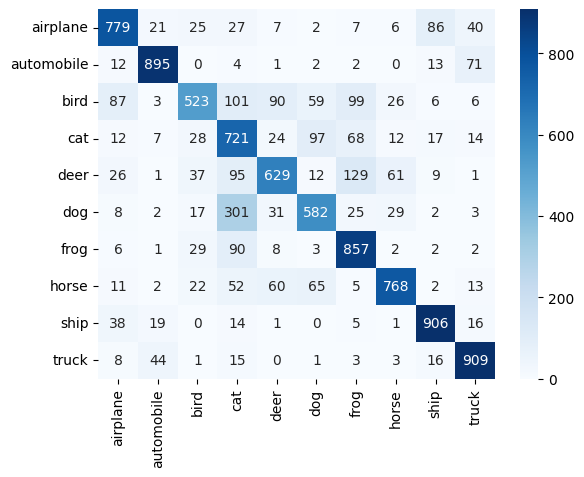

In [ ]:
cm = confusion_matrix(all_targets, all_preds)
classes = train_dataset.classes
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)

Visualize results by using matplotlib to plot curves of losses on training and validation set, training accuracy and test accuracy

Training history saved to training_history.png


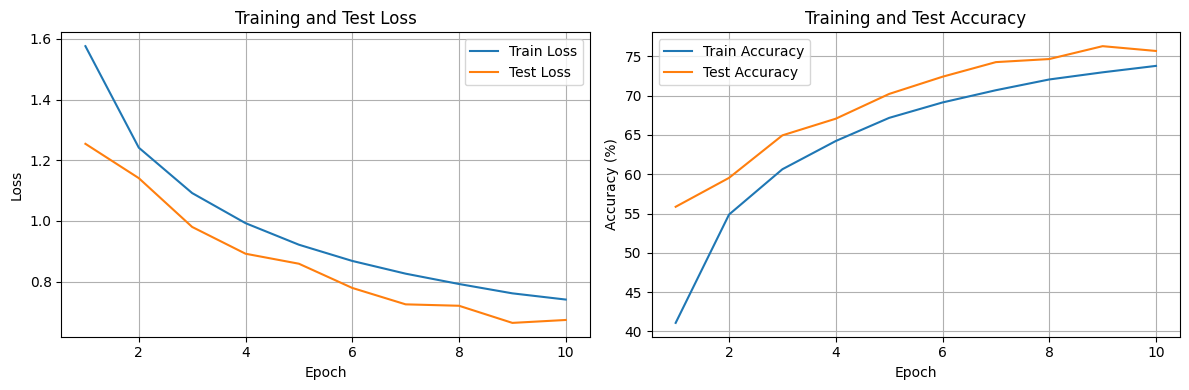

In [ ]:
# ============================================================================
# VISUALIZE TRAINING RESULTS
# ============================================================================

# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# LEFT PLOT: Loss over epochs
# Loss should generally decrease over time
# If test loss starts increasing while train loss decreases, that's overfitting
ax1.plot(range(1, num_epochs + 1), train_losses, label='Train Loss')
ax1.plot(range(1, num_epochs + 1), test_losses, label='Test Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Test Loss')
ax1.legend()
ax1.grid(True)

# RIGHT PLOT: Accuracy over epochs
# Accuracy should generally increase over time
# Large gap between train and test accuracy indicates overfitting
ax2.plot(range(1, num_epochs + 1), train_accuracies, label='Train Accuracy')
ax2.plot(range(1, num_epochs + 1), test_accuracies, label='Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training and Test Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()  # Adjust spacing between subplots
plt.savefig('training_history.png')  # Save the figure
print('Training history saved to training_history.png')

Save trained model to use later to test other images

In [ ]:
# ============================================================================
# SAVE THE TRAINED MODEL
# ============================================================================

# Save only the model's learned parameters (weights and biases)

torch.save(model.state_dict(), 'cifar-10_cnn.pth')
print('Model saved to cifar-10_cnn.pth')


Model saved to cifar-10_cnn.pth


Display samples of correctly and wrongly predicted images with their corresponding confidence levels

some images are predicted wrongly because the model hasn't learned enough, some images are blurry and some classes look similar.

CIFAR-10 Visualization Script

Using device: cuda

Loading CIFAR-10 dataset...
✓ Loaded 10000 test images

----------------------------------------------------------------------
Visualization 1: Random Dataset Samples
----------------------------------------------------------------------
✓ Dataset samples saved to dataset_samples.png


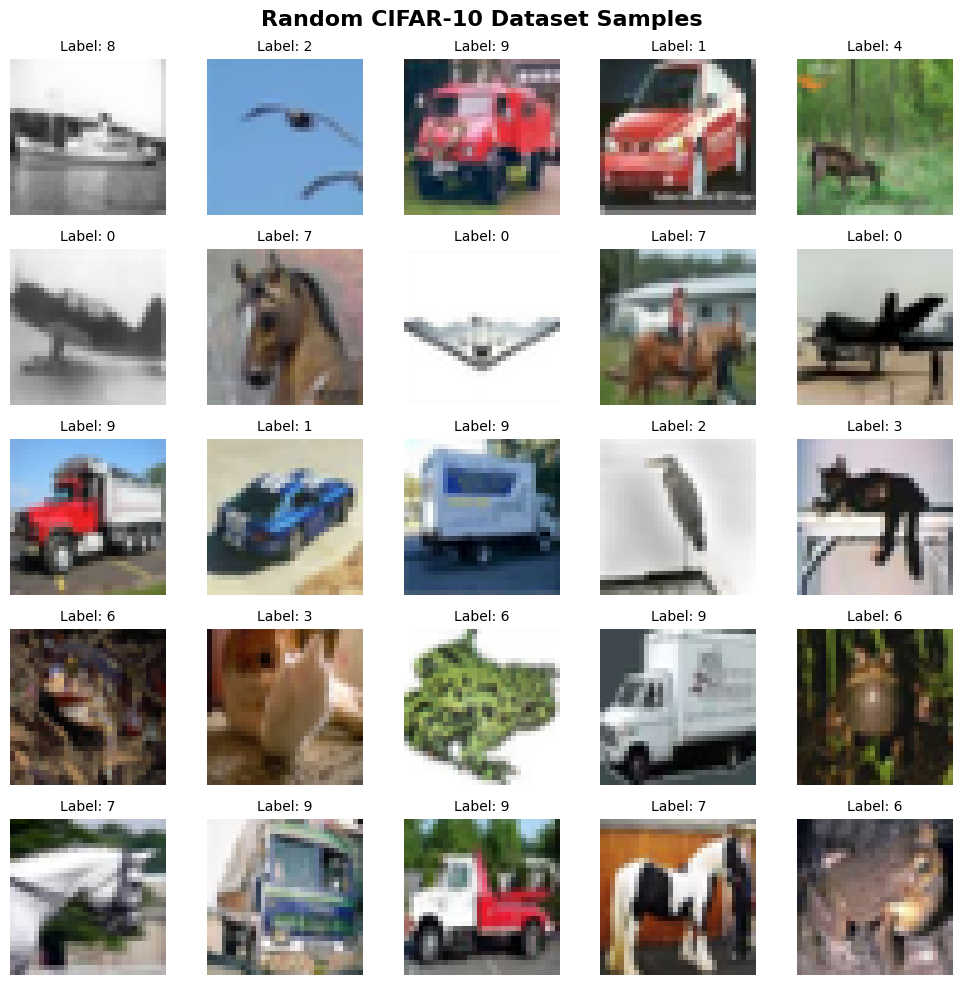


----------------------------------------------------------------------
Loading Trained Model for Predictions
----------------------------------------------------------------------
✓ Model loaded successfully from cifar-10_cnn.pth

----------------------------------------------------------------------
Visualization 2: Model Predictions (Mixed)
----------------------------------------------------------------------
✓ Predictions saved to predictions.png


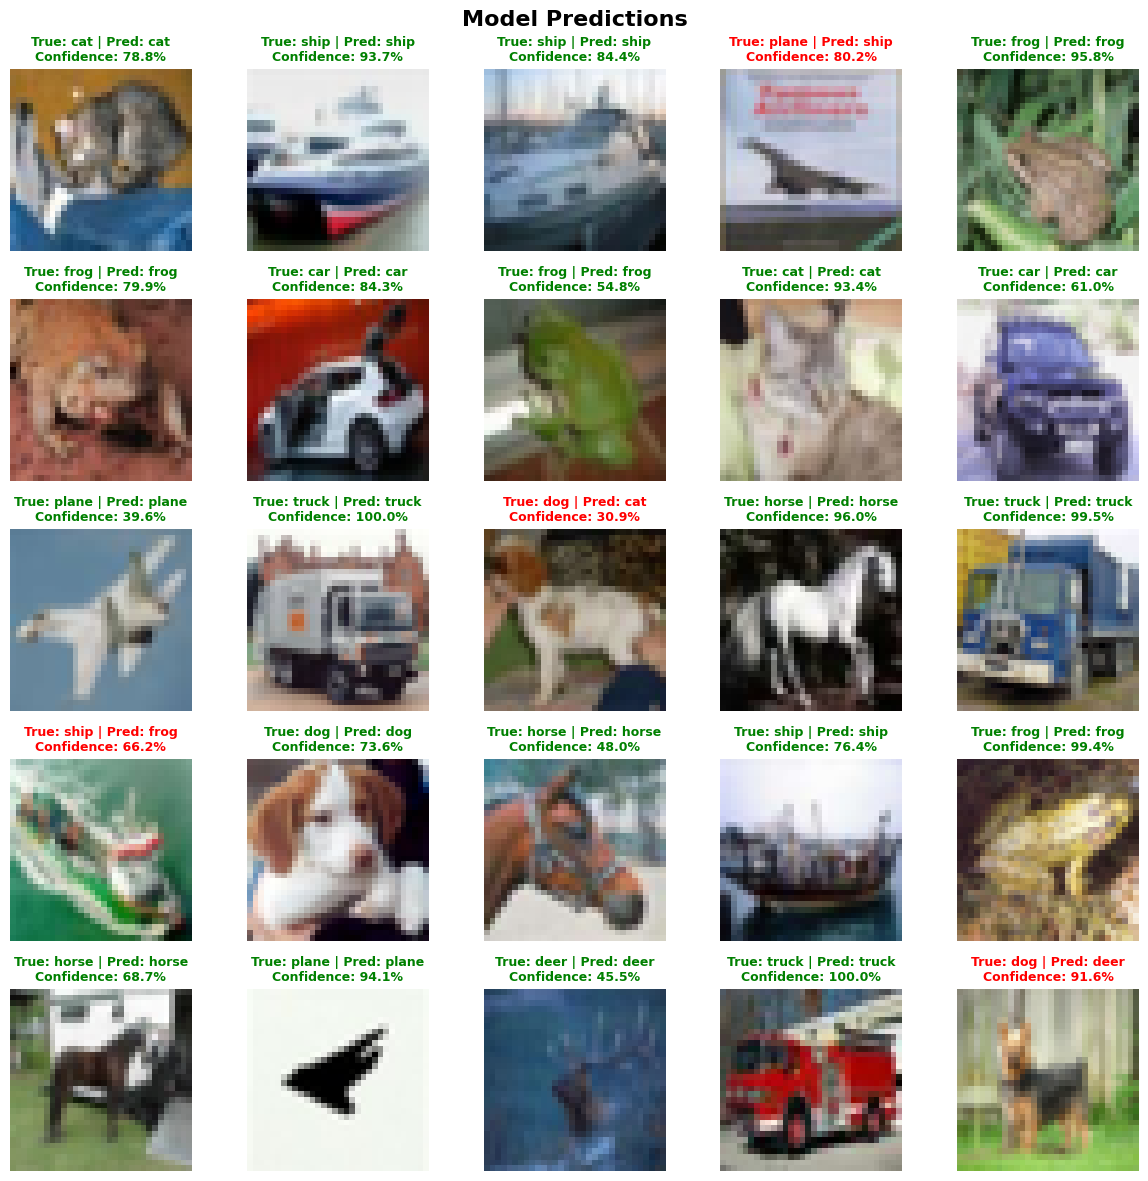


----------------------------------------------------------------------
Visualization 3: Incorrect Predictions Only
----------------------------------------------------------------------
✓ Predictions saved to predictions_incorrect.png


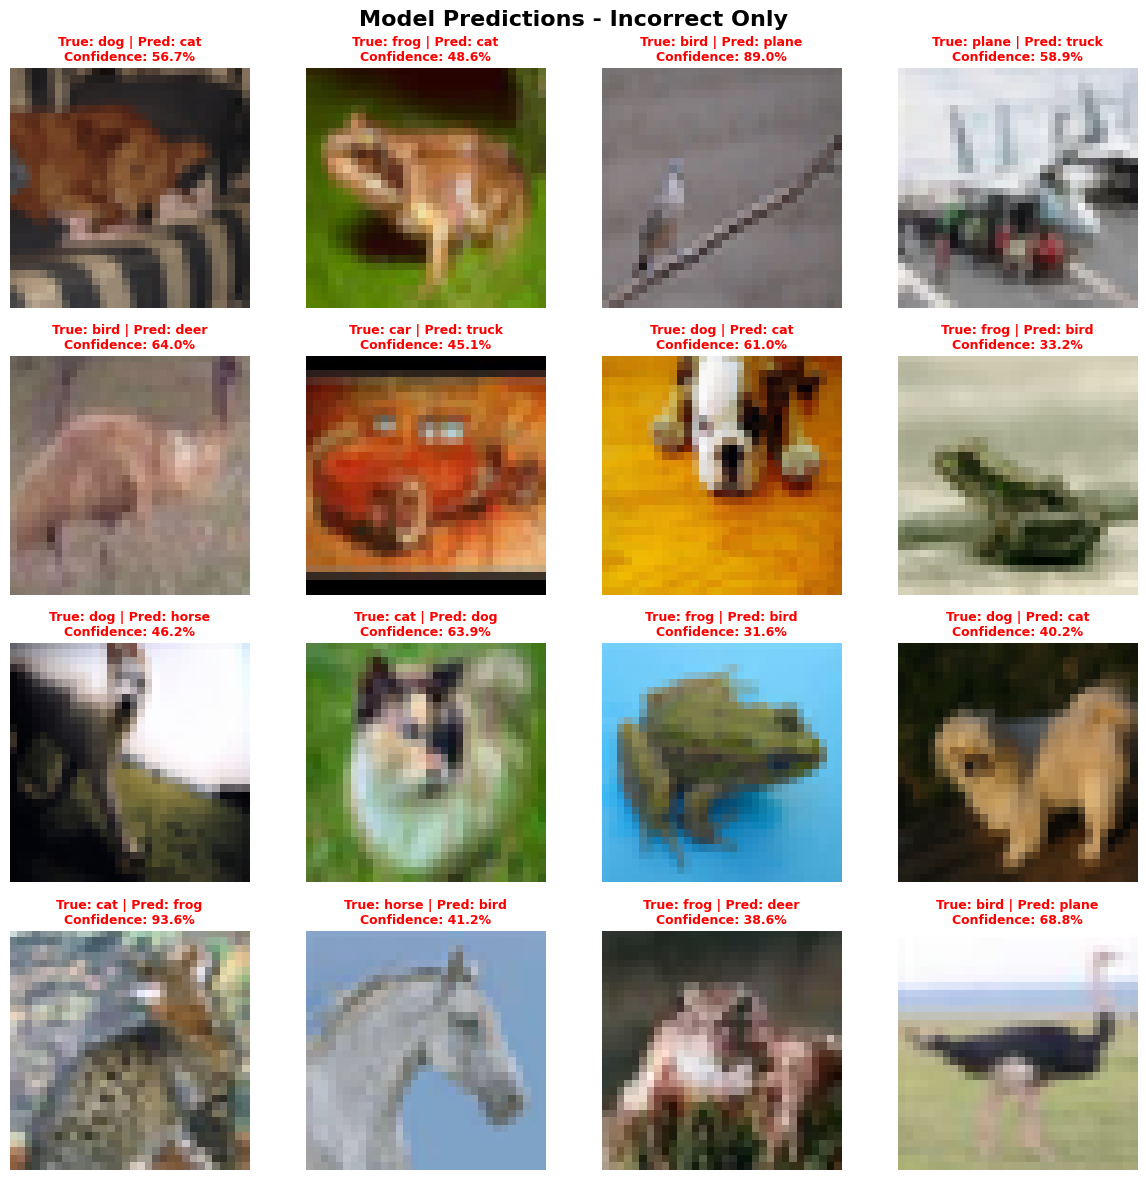


----------------------------------------------------------------------
Visualization 4: One Example Per Class
----------------------------------------------------------------------
✓ One per class visualization saved to one_per_class.png


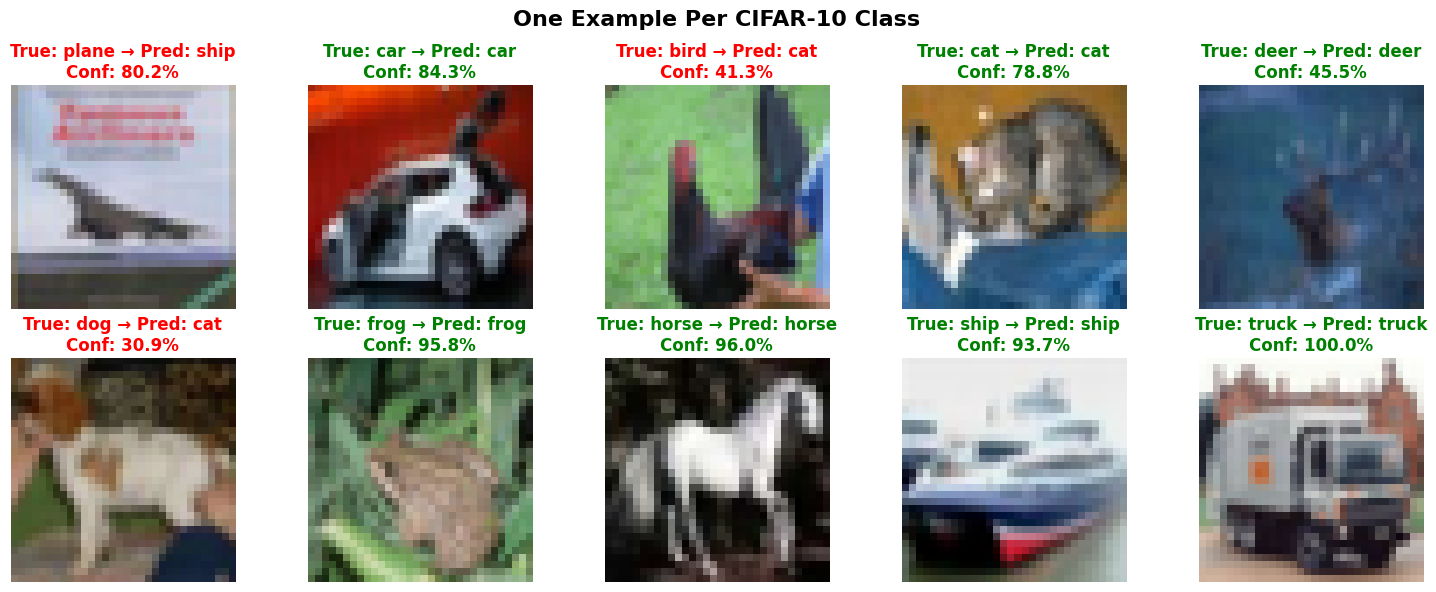


Visualization Complete!

Generated files:
  • dataset_samples.png - Random samples from CIFAR-10
  • predictions.png - Model predictions (mixed correct/incorrect)
  • predictions_incorrect.png - Only incorrect predictions
  • one_per_class.png - One example for each CIFAR-10 class (0-9)

Tips for interpreting results:
  • Green titles = correct predictions
  • Red titles = incorrect predictions
  • Confidence shows how sure the model is (0-100%)


In [ ]:
# ============================================================================
# VISUALIZATION FUNCTION 1: Display Random Dataset Samples
# ============================================================================
def visualize_dataset_samples(dataset, num_samples=25):
    """
    Display a grid of random samples from the dataset

    Args:
        dataset: CIFAR10 dataset object
        num_samples: number of images to display (default: 25 for 5x5 grid)
    """
    # Calculate grid dimensions (e.g., 25 samples = 5x5 grid)
    grid_size = int(np.sqrt(num_samples))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(10, 10))
    fig.suptitle('Random CIFAR-10 Dataset Samples', fontsize=16, fontweight='bold')

    random_indices = np.random.choice(len(dataset), num_samples, replace=False)

    # Loop through each subplot
    for idx, ax in enumerate(axes.flat):
        image, label = dataset[random_indices[idx]]
        # CIFAR-10 images are 3 channels, no need to squeeze for imshow
        # Denormalize for display
        image_np = (image.numpy().transpose((1, 2, 0)) * 0.5 + 0.5).clip(0, 1) # Denormalize and clip
        ax.imshow(image_np)
        ax.set_title(f'Label: {label}', fontsize=10)
        ax.axis('off')

    plt.tight_layout()
    plt.savefig('dataset_samples.png', dpi=150, bbox_inches='tight')
    print('✓ Dataset samples saved to dataset_samples.png')
    plt.show()

# ============================================================================
# VISUALIZATION FUNCTION 2: Display Model Predictions
# ============================================================================
def visualize_predictions(model, dataset, device, num_samples=25, show_incorrect=False):
    """
    Display images with their true labels and model predictions

    Args:
        model: trained CNN model
        dataset: CIFAR10 dataset object
        device: 'cuda' or 'cpu'
        num_samples: number of images to display
        show_incorrect: if True, only show incorrectly classified images
    """
    # Set model to evaluation mode
    model.eval()

    # Calculate grid size
    grid_size = int(np.sqrt(num_samples))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))
    title = 'Model Predictions - Incorrect Only' if show_incorrect else 'Model Predictions'
    fig.suptitle(title, fontsize=16, fontweight='bold')

    images_found = 0
    attempts = 0
    max_attempts = len(dataset) if show_incorrect else num_samples

    # Disable gradient calculation (we're not training)
    with torch.no_grad():
        while images_found < num_samples and attempts < max_attempts:
            if show_incorrect:
                idx = np.random.randint(0, len(dataset))
            else:
                idx = attempts

            image, true_label = dataset[idx]

            # Prepare image for model (add batch dimension)
            image_batch = image.unsqueeze(0).to(device)

            # Get model prediction
            output = model(image_batch)

            # Get the predicted class (digit with highest score)
            probabilities = torch.softmax(output, dim=1)  # Convert scores to probabilities
            confidence, predicted = probabilities.max(1)

            predicted_label = predicted.item()
            confidence_pct = confidence.item() * 100

            # If we only want incorrect predictions, skip correct ones
            if show_incorrect and predicted_label == true_label:
                attempts += 1
                continue

            # Get the subplot for this image
            ax = axes.flat[images_found]

            # Convert image to numpy for plotting (denormalize for display)
            image_np = (image.cpu().numpy().transpose((1, 2, 0)) * 0.5 + 0.5).clip(0, 1)

            # Display the image
            ax.imshow(image_np)

            # Create title with true label, prediction, and confidence
            # Color: green if correct, red if incorrect
            is_correct = predicted_label == true_label
            color = 'green' if is_correct else 'red'

            # CIFAR-10 classes
            classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

            title_text = f'True: {classes[true_label]} | Pred: {classes[predicted_label]}\n'
            title_text += f'Confidence: {confidence_pct:.1f}%'

            ax.set_title(title_text, fontsize=9, color=color, fontweight='bold')
            ax.axis('off')

            images_found += 1
            attempts += 1

    # If we couldn't find enough incorrect predictions
    if show_incorrect and images_found < num_samples:
        print(f'Note: Only found {images_found} incorrect predictions')
        # Hide unused subplots
        for idx in range(images_found, num_samples):
            axes.flat[idx].axis('off')

    plt.tight_layout()
    filename = 'predictions_incorrect.png' if show_incorrect else 'predictions.png'
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    print(f'✓ Predictions saved to {filename}')
    plt.show()

# ============================================================================
# VISUALIZATION FUNCTION 3: Confusion Matrix Style View
# ============================================================================
def visualize_one_per_class(model, dataset, device):
    """
    Display one example of each class (0-9) with predictions
    Useful to see how the model handles each class
    """
    model.eval()

    # Create figure with 2 rows, 5 columns (for 10 classes)
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('One Example Per CIFAR-10 Class', fontsize=16, fontweight='bold')

    # Find one example of each digit
    examples = {}

    with torch.no_grad():
        for idx in range(len(dataset)):
            image, label = dataset[idx]

            # If we haven't found this digit yet, save it
            if label not in examples:
                examples[label] = (image, idx)

            # Stop when we have all 10 digits
            if len(examples) == 10:
                break

        # Display each digit
        for class_id in range(10):
            row = class_id // 5
            col = class_id % 5
            ax = axes[row, col]

            image, idx = examples[class_id]

            # Get prediction
            image_batch = image.unsqueeze(0).to(device)
            output = model(image_batch)
            probabilities = torch.softmax(output, dim=1)
            confidence, predicted = probabilities.max(1)

            # Display image (denormalize for display)
            image_np = (image.cpu().numpy().transpose((1, 2, 0)) * 0.5 + 0.5).clip(0, 1)
            ax.imshow(image_np)

            # Title with prediction
            is_correct = predicted.item() == class_id
            color = 'green' if is_correct else 'red'
            classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

            title = f'True: {classes[class_id]} → Pred: {classes[predicted.item()]}\n'
            title += f'Conf: {confidence.item()*100:.1f}%'

            ax.set_title(title, color=color, fontweight='bold')
            ax.axis('off')

    plt.tight_layout()
    plt.savefig('one_per_class.png', dpi=150, bbox_inches='tight')
    print('✓ One per class visualization saved to one_per_class.png')
    plt.show()

# ============================================================================
# MAIN EXECUTION
# ============================================================================
if __name__ == "__main__":
    print("=" * 70)
    print("CIFAR-10 Visualization Script")
    print("=" * 70)

    # Set device
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'\nUsing device: {device}')

    # ========================================================================
    # LOAD THE DATASET
    # ========================================================================
    print('\nLoading CIFAR-10 dataset...')

    # Same transform as used in training
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

    # Load test dataset
    test_dataset = datasets.CIFAR10(root='./data', train=False,
                                  download=True, transform=transform)
    print(f'✓ Loaded {len(test_dataset)} test images')

    # ========================================================================
    # VISUALIZATION 1: Random Dataset Samples
    # ========================================================================
    print('\n' + '-' * 70)
    print('Visualization 1: Random Dataset Samples')
    print('-' * 70)
    visualize_dataset_samples(test_dataset, num_samples=25)

    # ========================================================================
    # LOAD THE TRAINED MODEL (optional - only for predictions)
    # ========================================================================
    print('\n' + '-' * 70)
    print('Loading Trained Model for Predictions')
    print('-' * 70)

    try:
        # Create model instance
        model = CIFAR().to(device)

        # Load the trained weights
        model.load_state_dict(torch.load('cifar-10_cnn.pth', map_location=device))
        print('✓ Model loaded successfully from cifar-10_cnn.pth')

        # ====================================================================
        # VISUALIZATION 2: Model Predictions (Correct and Incorrect)
        # ====================================================================
        print('\n' + '-' * 70)
        print('Visualization 2: Model Predictions (Mixed)')
        print('-' * 70)
        visualize_predictions(model, test_dataset, device,
                            num_samples=25, show_incorrect=False)

        # ====================================================================
        # VISUALIZATION 3: Only Incorrect Predictions
        # ====================================================================
        print('\n' + '-' * 70)
        print('Visualization 3: Incorrect Predictions Only')
        print('-' * 70)
        visualize_predictions(model, test_dataset, device,
                            num_samples=16, show_incorrect=True)

        # ====================================================================
        # VISUALIZATION 4: One Example Per Class
        # ====================================================================
        print('\n' + '-' * 70)
        print('Visualization 4: One Example Per Class')
        print('-' * 70)
        visualize_one_per_class(model, test_dataset, device)

    except FileNotFoundError:
        print('✗ Model file cifar-10_cnn.pth not found!')
        print('  Please ensure the model was trained and saved as cifar-10_cnn.pth')
        print('  Skipping prediction visualizations...')

    # ========================================================================
    # SUMMARY
    # ========================================================================
    print('\n' + '=' * 70)
    print('Visualization Complete!')
    print('=' * 70)
    print('\nGenerated files:')
    print('  • dataset_samples.png - Random samples from CIFAR-10')
    if 'model' in locals():
        print('  • predictions.png - Model predictions (mixed correct/incorrect)')
        print('  • predictions_incorrect.png - Only incorrect predictions')
        print('  • one_per_class.png - One example for each CIFAR-10 class (0-9)')
    print('\nTips for interpreting results:')
    print('  • Green titles = correct predictions')
    print('  • Red titles = incorrect predictions')
    print('  • Confidence shows how sure the model is (0-100%)')
    print('=' * 70)


Display training summary showing best epoch, model accuracy and optimizer used.

In [ ]:
# ============================================================================
# FINAL TRAINING SUMMARY
# ============================================================================

print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)

# Final Validation Accuracy
final_validation_accuracy = test_accuracies[-1]
print(f"Final Validation Accuracy: {final_validation_accuracy:.2f}%")

# Best Epoch (based on best_test_loss)
if best_model_state is not None:
    # Find the epoch number corresponding to the best_test_loss
    # Note: test_losses stores loss for each epoch, so index + 1 gives epoch number
    try:
        best_epoch_index = test_losses.index(best_test_loss)
        best_epoch = best_epoch_index + 1
        print(f"Best Epoch (based on lowest test loss): {best_epoch}")
    except ValueError:
        print("Could not determine best epoch based on best_test_loss.")
else:
    print("No best model state saved (early stopping might have prevented it).")

# Optimizer Used
optimizer_name = optimizer.__class__.__name__
print(f"Optimizer Used: {optimizer_name}")

# Learning Rate
print(f"Learning Rate: {learning_rate}")

# Regularization techniques applied
# Retrieve dropout rate from the model definition if possible
# Assuming the dropout layer is named 'dropout' in the model
model_dropout_rate = 0.0 # Default if not found
for module in model.modules():
    if isinstance(module, nn.Dropout):
        model_dropout_rate = module.p
        break

regularization_info = []
if model_dropout_rate > 0:
    regularization_info.append(f"Dropout (p={model_dropout_rate})")

# Check weight decay in optimizer
if 'weight_decay' in optimizer.defaults and optimizer.defaults['weight_decay'] > 0:
    regularization_info.append(f"L2 Regularization (Weight Decay={optimizer.defaults['weight_decay']})")

if regularization_info:
    print("Regularization Techniques Applied:")
    for tech in regularization_info:
        print(f"  - {tech}")
else:
    print("No explicit regularization techniques applied (besides implicit from architecture).")

print("=" * 60)


TRAINING SUMMARY
Final Validation Accuracy: 75.69%
Best Epoch (based on lowest test loss): 9
Optimizer Used: Adam
Learning Rate: 0.001
Regularization Techniques Applied:
  - Dropout (p=0.9)
  - L2 Regularization (Weight Decay=1e-05)
